/home/bobur/AI_Project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/bobur/AI_Project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Raw Top 5 MI Sum: 3.275181039732886
Feature Top 5 MI Sum: 5.820139514709362
Improvement Percentage: 77.70%
Max Correlation Raw: 0.9543434596579329
Max Correlation Feature: 0.9617595445996238
Correlation Improvement: 0.78%


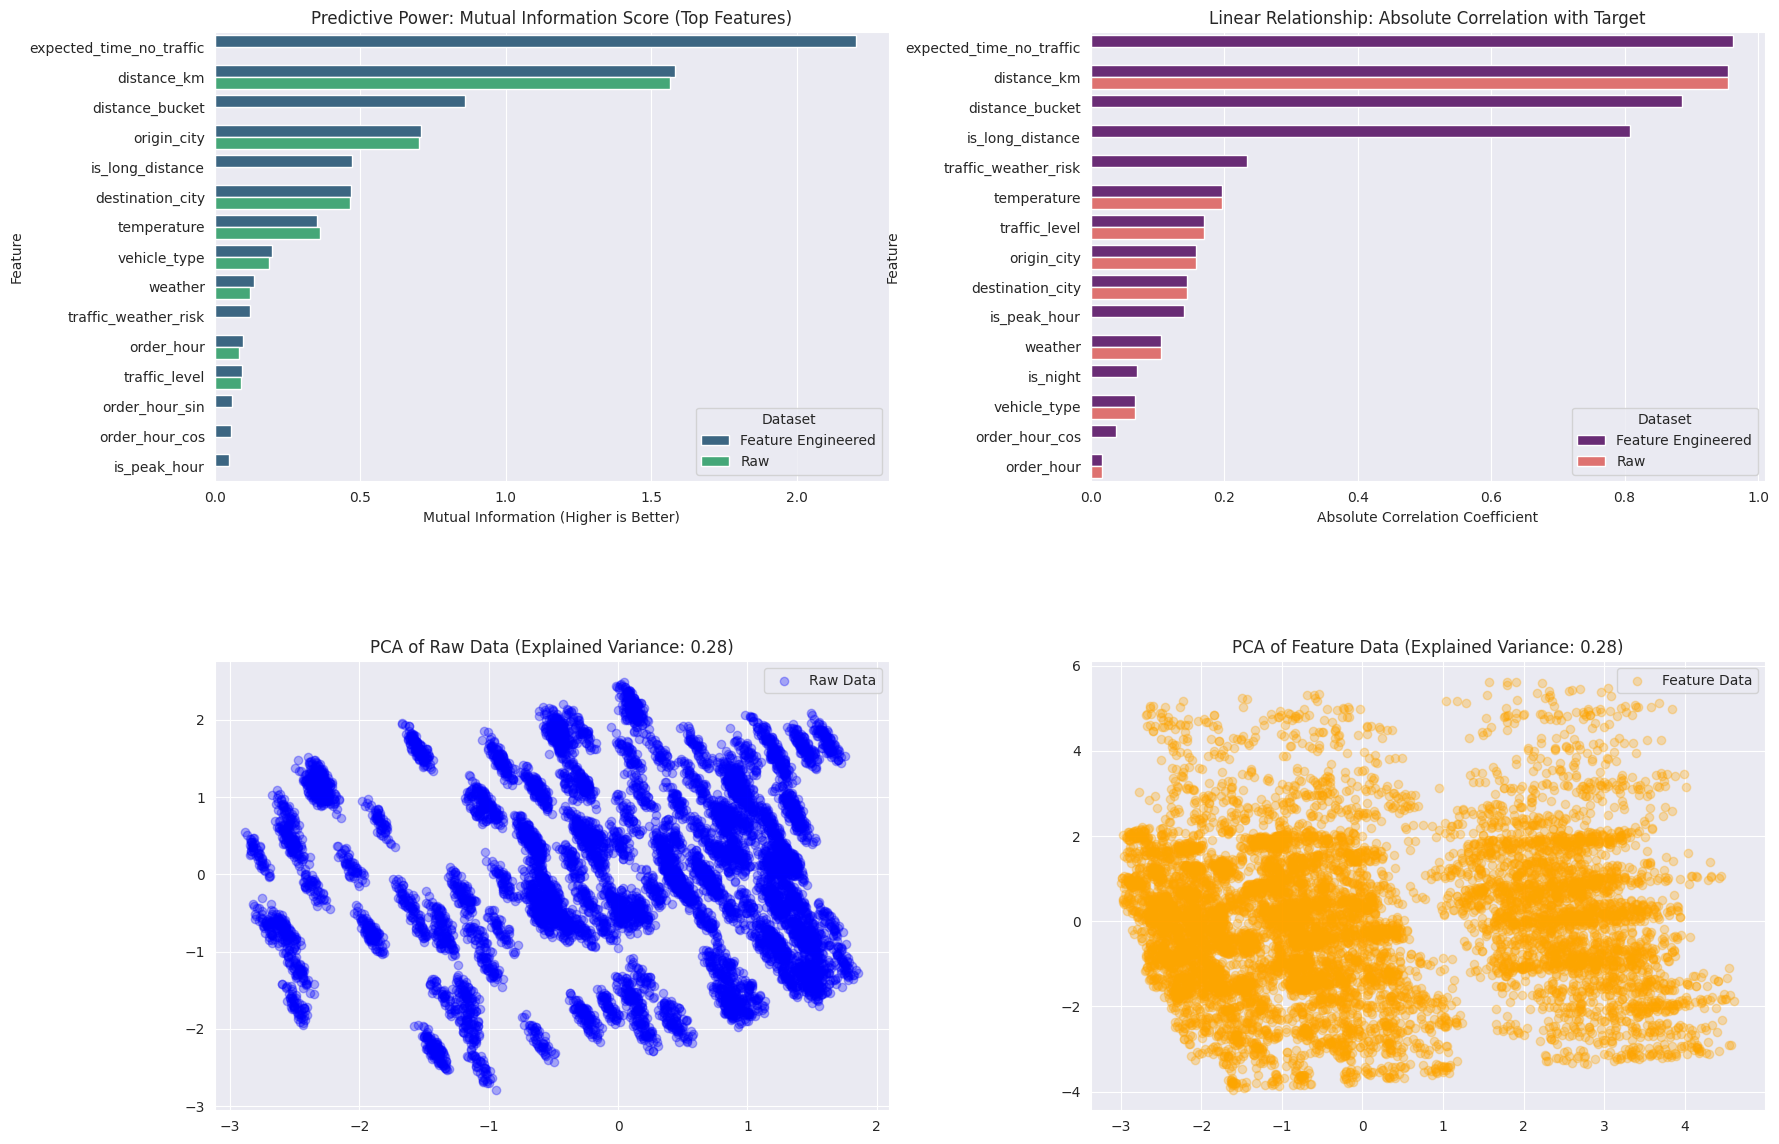

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load datasets
df_raw = pd.read_csv('dataset/raw_data.csv')
df_feature = pd.read_csv('dataset/feature_data_v2.csv')

# Drop order_id from raw as it's not predictive
if 'order_id' in df_raw.columns:
    df_raw = df_raw.drop(columns=['order_id'])

# Remove rows in raw that might have been dropped in feature engineering to match sizes for fair comparison (if needed)
# But since we compare dataset quality, we treat them as independent sets.

# 1. Preprocessing for Metric Calculation
# We need to convert categorical text to numbers to calculate correlation and MI
def encode_df(df):
    df_encoded = df.copy()
    le = LabelEncoder()
    for col in df_encoded.select_dtypes(include=['object', 'bool']).columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    return df_encoded

df_raw_enc = encode_df(df_raw)
df_feature_enc = encode_df(df_feature)

# Target variable
target = 'delivery_time_hours'
X_raw = df_raw_enc.drop(columns=[target])
y_raw = df_raw_enc[target]
X_feature = df_feature_enc.drop(columns=[target])
y_feature = df_feature_enc[target]

# 2. Calculate Mutual Information (MI)
# Using a sample to speed up if dataset is huge, but 70k is manageable.
# Let's take a sample of 10000 for speed in the VM environment.
sample_size = 10000
seed = 42

X_raw_sample = X_raw.sample(n=sample_size, random_state=seed)
y_raw_sample = y_raw.loc[X_raw_sample.index]

X_feature_sample = X_feature.sample(n=sample_size, random_state=seed)
y_feature_sample = y_feature.loc[X_feature_sample.index]

mi_raw = mutual_info_regression(X_raw_sample, y_raw_sample, random_state=seed)
mi_feature = mutual_info_regression(X_feature_sample, y_feature_sample, random_state=seed)

mi_raw_series = pd.Series(mi_raw, index=X_raw.columns).sort_values(ascending=False)
mi_feature_series = pd.Series(mi_feature, index=X_feature.columns).sort_values(ascending=False)

# 3. Calculate Correlations with Target
corr_raw = df_raw_enc.corrwith(df_raw_enc[target]).abs().sort_values(ascending=False).drop(target)
corr_feature = df_feature_enc.corrwith(df_feature_enc[target]).abs().sort_values(ascending=False).drop(target)

# 4. Visualization
fig = plt.figure(figsize=(20, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot 1: Mutual Information Comparison (Top 10)
ax1 = fig.add_subplot(2, 2, 1)
# Combine top 5 from raw and top 10 from feature to see the difference
top_features_plot = pd.concat([mi_raw_series.head(5), mi_feature_series.head(10)]).drop_duplicates()
# Create a dataframe for plotting
data_plot = []
for idx, val in mi_raw_series.items():
    data_plot.append({'Feature': idx, 'MI Score': val, 'Dataset': 'Raw'})
for idx, val in mi_feature_series.items():
    data_plot.append({'Feature': idx, 'MI Score': val, 'Dataset': 'Feature Engineered'})
df_mi_plot = pd.DataFrame(data_plot).sort_values('MI Score', ascending=False)
# Limit to top 15 unique features overall
top_features = df_mi_plot['Feature'].unique()[:15]
df_mi_plot = df_mi_plot[df_mi_plot['Feature'].isin(top_features)]

sns.barplot(data=df_mi_plot, x='MI Score', y='Feature', hue='Dataset', ax=ax1, palette='viridis')
ax1.set_title('Predictive Power: Mutual Information Score (Top Features)')
ax1.set_xlabel('Mutual Information (Higher is Better)')

# Plot 2: Correlation with Target
ax2 = fig.add_subplot(2, 2, 2)
# Similar approach for correlation
data_corr_plot = []
for idx, val in corr_raw.items():
    data_corr_plot.append({'Feature': idx, 'Correlation': val, 'Dataset': 'Raw'})
for idx, val in corr_feature.items():
    data_corr_plot.append({'Feature': idx, 'Correlation': val, 'Dataset': 'Feature Engineered'})
df_corr_plot = pd.DataFrame(data_corr_plot).sort_values('Correlation', ascending=False)
top_corr_features = df_corr_plot['Feature'].unique()[:15]
df_corr_plot = df_corr_plot[df_corr_plot['Feature'].isin(top_corr_features)]

sns.barplot(data=df_corr_plot, x='Correlation', y='Feature', hue='Dataset', ax=ax2, palette='magma')
ax2.set_title('Linear Relationship: Absolute Correlation with Target')
ax2.set_xlabel('Absolute Correlation Coefficient')

# Plot 3: 2D PCA "Information Space"
# We standardize and run PCA on both to see how "spread out" the data is.
# A better feature space often has more variance explained by the first few components
# OR distinct structures. Here we just visualize the first 2 components.
scaler = StandardScaler()
X_raw_scaled = scaler.fit_transform(X_raw_sample)
X_feature_scaled = scaler.fit_transform(X_feature_sample)

pca = PCA(n_components=2)
raw_pca = pca.fit_transform(X_raw_scaled)
feature_pca = pca.fit_transform(X_feature_scaled)

ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(raw_pca[:, 0], raw_pca[:, 1], alpha=0.3, c='blue', label='Raw Data')
ax3.set_title(f'PCA of Raw Data (Explained Variance: {pca.explained_variance_ratio_.sum():.2f})')
ax3.legend()

ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(feature_pca[:, 0], feature_pca[:, 1], alpha=0.3, c='orange', label='Feature Data')
ax4.set_title(f'PCA of Feature Data (Explained Variance: {pca.explained_variance_ratio_.sum():.2f})')
ax4.legend()

plt.savefig('visualizations/data_quality_viz.png')

# 5. Quantification of Improvement
# Metric: Sum of Mutual Information of top 5 features
raw_quality_score = mi_raw_series.head(5).sum()
feature_quality_score = mi_feature_series.head(5).sum()
improvement_pct = ((feature_quality_score - raw_quality_score) / raw_quality_score) * 100

print(f"Raw Top 5 MI Sum: {raw_quality_score}")
print(f"Feature Top 5 MI Sum: {feature_quality_score}")
print(f"Improvement Percentage: {improvement_pct:.2f}%")

# Check the top correlated feature improvement
raw_max_corr = corr_raw.max()
feature_max_corr = corr_feature.max()
print(f"Max Correlation Raw: {raw_max_corr}")
print(f"Max Correlation Feature: {feature_max_corr}")
print(f"Correlation Improvement: {((feature_max_corr - raw_max_corr)/raw_max_corr)*100:.2f}%")